## HW 1 - MNIST Classifier with Starter Code

## **Intro**

In this homework (HW1), you will implement a handwritten digit classifier using the MNIST dataset and PyTorch. This assignment serves as an introduction to the core workflow of training neural networks, including data loading, model design, training, and evaluation.

Rather than building everything from scratch, you are provided with starter code that sets up the dataset and training pipeline. Your task is to complete the missing components to build a working classifier.

**The goals of this assignment are to help you become familiar with:**

* The PyTorch programming model
* The structure of a neural network classifier
* The end-to-end training and evaluation process

**The workflow of this notebook is organized as follows:**

**1. MNIST Dataset and Data Loading<br/>**
We begin by introducing the MNIST dataset and demonstrate how images and labels are loaded using PyTorch’s Dataset and DataLoader abstractions.

**2. Model Design<br/>**
You will design a simple neural network classifier for MNIST by defining the model architecture and implementing the forward pass.

**3. Loss Function and Optimizer<br/>**
We introduce the loss function and optimizer used for classification and set up the training configuration.

**4. Training Loop<br/>**
You will complete the training loop to train the model on the MNIST training set.

**5. Evaluation<br/>**
Finally, you will evaluate the trained model on the MNIST test set and report the classification accuracy.

**NOTE:** A correctly implemented model should achieve ≥90% accuracy on the MNIST test set.


**Helpful Links**

Here are some useful resources to guide your implementation:

MNIST Classification with PyTorch (Kaggle Notebook)
https://www.kaggle.com/code/geekysaint/solving-mnist-using-pytorch

PyTorch Official Tutorials – Getting Started
https://pytorch.org/tutorials/

TorchVision Datasets Documentation
https://pytorch.org/vision/stable/datasets.html

## **Import Packages**

First, we need to import packages that will be used later.

In this homework, we highly rely on **torchvision**, a library of PyTorch.

In [ ]:
# Imports
import torch
import torchvision ## Contains some utilities for working with the image data
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
#%matplotlib inline
import torchvision.transforms as transforms
from torch.utils.data import random_split
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch.nn as nn


## **About the MNIST Dataset**

Modified National Institute of Standards and Technology (MNIST) Handwritten Digits Databases is a dataset consists of 28px grayscale images of handwritten disgits (0-9) with labels for each image matching the images to the digits it reprsents.


In [ ]:
# Load MNIST dataset
transform = transforms.ToTensor()

train_dataset = MNIST(
    root="data/",
    train=True,
    download=True,
    transform=transform
)

test_dataset = MNIST(
    root="data/",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
mnist_dataset = train_dataset  # fix: define mnist_dataset

image_tensor, label = mnist_dataset[0]

# TODO 0: Print dimensions of the image tensor
print("Image tensor shape:", image_tensor.shape)
print("Label:", label)


Image tensor shape: torch.Size([1, 28, 28])
Label: 5


## **Model Definition**

Define the layers of the network and setting up the forward function

In [ ]:
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO 1: Define layers
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # x shape: [batch_size, 1, 28, 28]

        # TODO 2:
        x = x.view(x.size(0), -1)      # flatten to [batch_size, 784]
        x = F.relu(self.fc1(x))        # hidden layer + ReLU
        x = self.fc2(x)                # logits (no softmax)
        return x


## **Initialize Model, Loss, Optimizer**


In [ ]:
model = MNISTClassifier()

# TODO 3: Loss function
criterion = nn.CrossEntropyLoss()

# TODO 4: Optimizer + learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


## **Training Loop**

In [ ]:
num_epochs = 5
train_losses = []
test_accuracies = []
for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0

    for images, labels in train_loader:

        # TODO 5:
        # 1. Zero the gradients
        optimizer.zero_grad()

        # 2. Forward pass
        outputs = model(images)

        # 3. Compute loss
        loss = criterion(outputs, labels)

        # 4. Backward pass
        loss.backward()

        # 5. Update parameters
        optimizer.step()

        # Accumulate loss
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)   # one number per epoch
    train_losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss:.4f}")

# ----- Evaluation Loop -----
    model.eval()
    correct = 0
    total = 0


    with torch.no_grad():
        for images, labels in test_loader:
            # TODO 6:
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    test_accuracies.append(accuracy)
    print(f"Test Accuracy: {accuracy:.2%}")



Epoch [1/5], Loss: 330.6490
Test Accuracy: 94.28%
Epoch [2/5], Loss: 154.9838
Test Accuracy: 95.76%
Epoch [3/5], Loss: 106.9244
Test Accuracy: 96.59%
Epoch [4/5], Loss: 81.4890
Test Accuracy: 97.37%
Epoch [5/5], Loss: 64.0112
Test Accuracy: 97.39%


## **Graphing Results**

After finishing training, the following code will graph the results

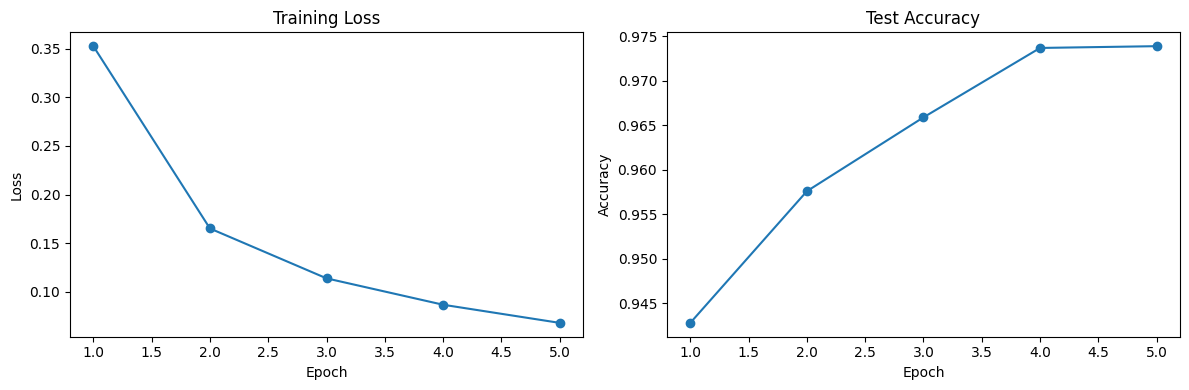

In [ ]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

# Training Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

# Test Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, test_accuracies, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Test Accuracy")

plt.tight_layout()
plt.show()